<a href="https://colab.research.google.com/github/Hibashanti/Prediction-Product-Sale/blob/main/Prediction%20of%20Product%20Sale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sale
- Author : Hiba Shanti

## Project overview

## 1- Import Libraries and Load the Data

*   List item
*   List item



In [1]:
# Mount to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 ### 1.1-Imports Libraries

In [2]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',100)
import missingno
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector as make_columns_selector
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Set pandas as the default output for sklearn
from sklearn import set_config
set_config(transform_output='pandas')

1.2- Load The Dataset

In [3]:
path="/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"

In [4]:
df_sales=pd.read_csv(path)
df_sales

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# 2- Inspecting The Data

In [5]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#### 2.1- Rows and Columns
- Number of Rows
'8523'

- Number od Columns
'12'


In [7]:
df_sales.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


### 2.2-Types of Data
- float 4
- Int    1
- object 7

## 3- Data Cleaning






- 3.1-Inspecting and Droping Duplicates

In [8]:
df_sales.duplicated().sum()

np.int64(0)

- there is zero duplicates in the dataset

- 3.2-Inspecting Missing Values

In [9]:
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [10]:
#check for column type :
df_sales["Item_Weight"].dtypes

dtype('float64')

In [11]:
# Counts different Types availabe
count_types=df_sales["Item_Type"].value_counts()
count_types


,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [12]:
#calculate the mean value of weight for each item_type and fill weight mean value in its missing in Item_Weight :
mean_by_type=df_sales.groupby("Item_Type")["Item_Weight"].mean()
for item_type in mean_by_type.index :
  df_sales.loc[(df_sales["Item_Type"] == item_type) & (df_sales["Item_Weight"].isna()), "Item_Weight"] = mean_by_type[item_type]

In [13]:
#Confirm no Missing Values in Item_weight
df_sales["Item_Weight"].isna().sum()

np.int64(0)

In [14]:
#check Type for Outlet_Size column
df_sales["Outlet_Size"].dtypes

dtype('O')

In [15]:
df_sales["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [16]:
df_sales["Outlet_Size"]=df_sales["Outlet_Size"].fillna("MISSING")
df_sales["Outlet_Size"]

,Outlet_Size
0,Medium
1,Medium
2,Medium
3,MISSING
4,High
...,...
8518,High
8519,MISSING
8520,Small
8521,Medium


In [17]:
df_sales["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2793
MISSING,2410
Small,2388
High,932


In [18]:
df_sales.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


- Inspect Inconsistanses
  - 1- Catagorical Values
  - 2- Numerical Values

In [19]:
# Display categorical columns
cat_col=df_sales.select_dtypes("object").columns
cat_col

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [20]:
#to check for inconsistances in each category:
for col in cat_col :
  print(f"Value Counts for {col}")
  print(df_sales[col].value_counts())
  print('\n')

Value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [21]:
df_sales["Item_Fat_Content"]=df_sales["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg" : "Regular"})
df_sales["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


- Summary Statistics for numerical Data

In [22]:
# Display numeriacl columns
num_col=df_sales.select_dtypes("number").columns
num_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [23]:
#The summury statistics for the numerical values
df_sales[num_col].describe()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857890,0.066132,140.992782,1997.831867,2181.288914
std,4.232804,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.867061,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## 4-Data Visualizayion

In [24]:
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


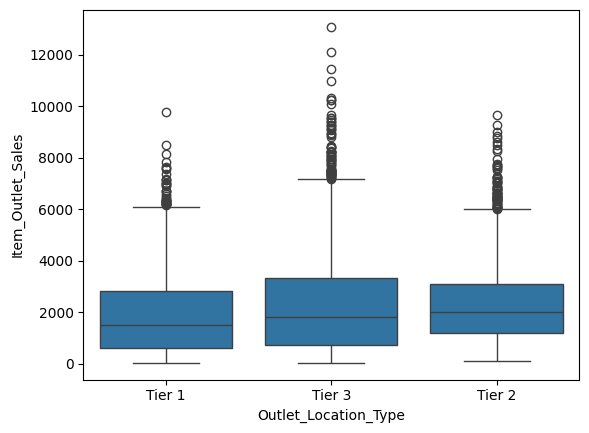

In [25]:
# Display the relation between Outlet_Location_Type and Item_Outlet_Salesusing Boxplots
sns.boxplot(data=df_sales, x='Outlet_Location_Type', y="Item_Outlet_Sales");

In [26]:
# Visualize the relation between Item_type and Item_Visibility
#grouping the values
visual=df_sales.groupby("Item_Type")["Item_Visibility"].mean()
visual

,Item_Visibility
Item_Type,
Baking Goods,0.069169
Breads,0.066255
Breakfast,0.085723
Canned,0.068129
Dairy,0.072427
Frozen Foods,0.065645
Fruits and Vegetables,0.068513
Hard Drinks,0.064943
Health and Hygiene,0.055216


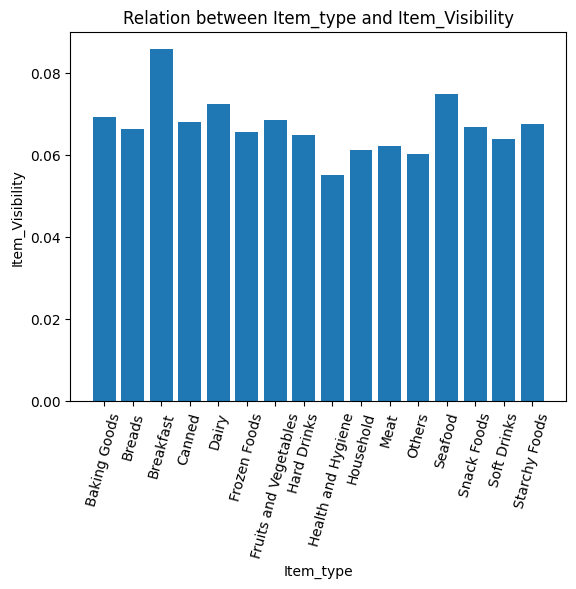

In [27]:
# Drow the Barplot to visualize the relation between Item_type and Item_Visibility
fig, ax=plt.subplots()
ax.bar(visual.index,visual.values)
ax.tick_params(axis='x', rotation=75)
ax.set_title("Relation between Item_type and Item_Visibility")
ax.set_xlabel("Item_type")
ax.set_ylabel("Item_Visibility");

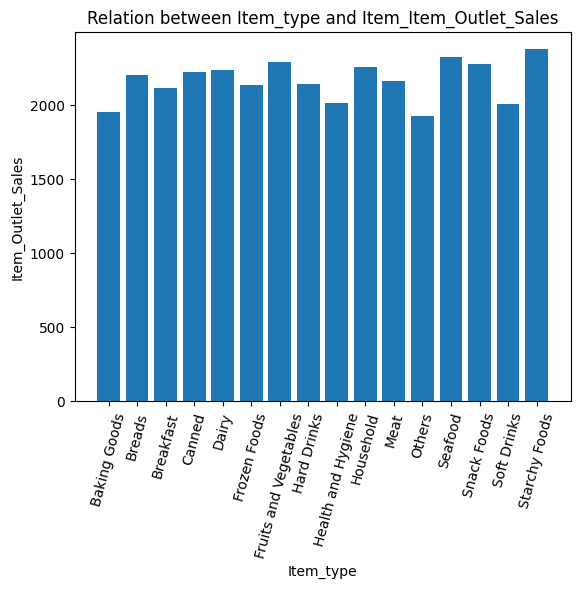

In [28]:
#Relation between Item_Type and Item_Outlet_Sales
Type_MRP=df_sales.groupby("Item_Type")["Item_Outlet_Sales"].mean()
# drow the plot
fig, ax=plt.subplots()
ax.bar(Type_MRP.index,Type_MRP.values)
ax.tick_params(axis='x', rotation=75)
ax.set_title("Relation between Item_type and Item_Item_Outlet_Sales")
ax.set_xlabel("Item_type")
ax.set_ylabel("Item_Outlet_Sales");

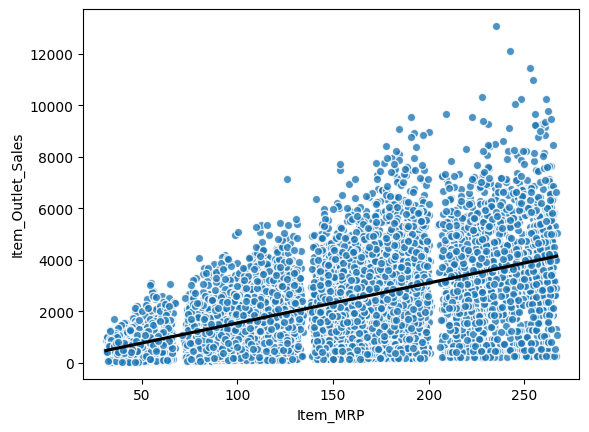

In [29]:
#Display the Relation between Item_MRP and Item_Outlet_Sales
line_kws=dict(color="black")
scatter_kws=dict(edgecolor="White")
sns.regplot(data=df_sales, x='Item_MRP', y='Item_Outlet_Sales',line_kws=line_kws, scatter_kws=scatter_kws);


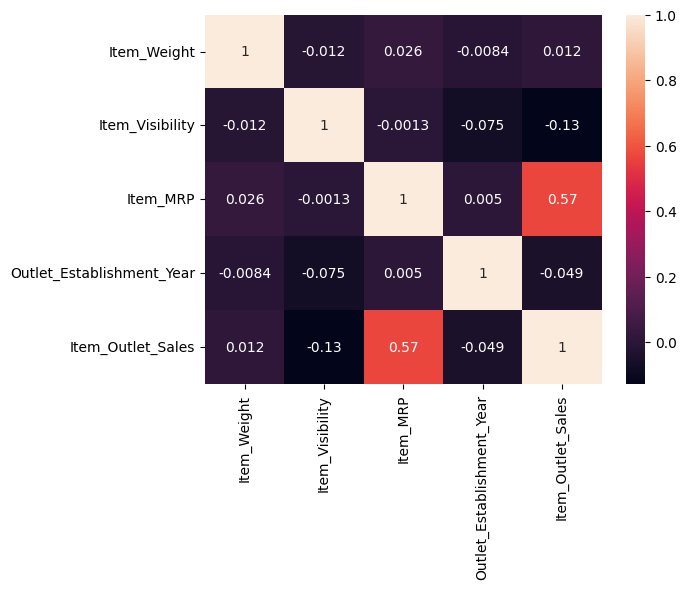

In [30]:
# Correlation between all numerical data using Heatmap
corr_relationship=df_sales.corr(numeric_only=True)
sns.heatmap(corr_relationship, color="Blue", annot=True);

#Modeling

In [31]:
# Reload the data
path="/content/drive/MyDrive/Axsos Academy/AXSOSACADEMY-1/02-IntroML/Week05/Data/sales_predictions_2023.csv"

In [32]:
df=pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [33]:
#Check for Dublicates
df.duplicated().sum()

np.int64(0)

In [34]:
#Check for inconsistancy - categorical
# select categorical columns
cat_col=df.select_dtypes("object").columns
cat_col

# Inconsistancy
for col in cat_col :
  print(f"Value Counts for {col}")
  print(df[col].value_counts())
  print('\n')

Value Counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value Counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Value Counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value Counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [35]:
df["Item_Fat_Content"]=df["Item_Fat_Content"].replace({"LF":"Low Fat", "low fat":"Low Fat", "reg" : "Regular"})
df["Item_Fat_Content"].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [36]:
# Check inconsistancy in numerical columns
# Display numeriacl columns
num_col=df.select_dtypes("number").columns
num_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [37]:
#The summury statistics for the numerical values
df[num_col].describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


#Check for Missing Values

In [38]:
# Dropping the "Item_Identifier" feature due to its high cardinality
df=df.drop(columns="Item_Identifier")

In [39]:
# You should identify the features (X) and target (y)
X=df.drop(columns="Item_Outlet_Sales")
y=df["Item_Outlet_Sales"]

In [56]:
#Split the dataset to testing and training data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,16.350,Low Fat,0.029565,Household,256.4646,OUT018,2009,Medium,Tier 3,Supermarket Type2
7510,15.250,Regular,0.000000,Snack Foods,179.7660,OUT018,2009,Medium,Tier 3,Supermarket Type2
5828,12.350,Regular,0.158716,Meat,157.2946,OUT049,1999,Medium,Tier 1,Supermarket Type1
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,OUT035,2004,Small,Tier 2,Supermarket Type1
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,OUT045,2002,NaN,Tier 2,Supermarket Type1


In [41]:
X_train["Outlet_Size"].value_counts()

,count
Outlet_Size,
Medium,2103
Small,1788
High,689


In [42]:
X_train["Outlet_Location_Type"].value_counts()

,count
Outlet_Location_Type,
Tier 3,2531
Tier 2,2106
Tier 1,1755


In [43]:
# Create tuple for ordinal data
#select the ordinal columns
ord_col=["Outlet_Size","Outlet_Location_Type"]
#Impute the startegy
ord_imputer=SimpleImputer(strategy="constant",fill_value="NA")
# Select order in columns
ord_size=["Small", "Medium","High","NA"]
ord_location=["Tier 1","Tier 2","Tier 3"]
# Assign the order to columns
col_ord=[ord_size,ord_location]
# Run the encoder
ord_encoder=OrdinalEncoder(categories=col_ord)
# define the scaler
ord_scaler=StandardScaler()
# Define a pipeline
ord_pipe=make_pipeline(ord_imputer,ord_encoder,ord_scaler)
#set the Tuple
ord_tuple=("ordinal",ord_pipe,ord_col)


In [44]:
# Create tuple for categorical data
#select the categorical columns
cat_col=X_train.select_dtypes("object").drop(columns=ord_col).columns
#Impute the startegy
cat_imputer=SimpleImputer(strategy="constant",fill_value="NA")
# Run the onehotencoder
cat_ohe=OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Define a pipeline
cat_pipe=make_pipeline(cat_imputer,cat_ohe)
#set the Tuple
cat_tuple=("categorical",cat_pipe,cat_col)


In [45]:
# Create tuple for numerical data
#select the numerical columns
num_col=X_train.select_dtypes("number").columns
#Impute the startegy
num_imputer=SimpleImputer(strategy="mean")
#Scale the data
num_scaler=StandardScaler()
# Define a pipeline
num_pipe=make_pipeline(num_imputer,num_scaler)
#set the Tuple
num_tuple=("numerical",num_pipe,num_col)

In [46]:
# Identify the columns transformer
col_transformer=ColumnTransformer([ord_tuple,cat_tuple,num_tuple],remainder="passthrough",verbose_feature_names_out=False)
col_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Small',
                                                                              'Medium',
                                                                              'High',
                                                                              'NA'],
                                                                             ['Tier '
                                                                              '1',
                                                                              'Tier '
                                                                              '2',
                                                                              'Tier '
                                                                              '3']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Outlet_Size', 'Outlet_Location_Type']),
                                ('categor...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object')),
                                ('numerical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [47]:
# fit the column transformer
col_transformer.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['Small',
                                                                              'Medium',
                                                                              'High',
                                                                              'NA'],
                                                                             ['Tier '
                                                                              '1',
                                                                              'Tier '
                                                                              '2',
                                                                              'Tier '
                                                                              '3']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Outlet_Size', 'Outlet_Location_Type']),
                                ('categor...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object')),
                                ('numerical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [48]:
#Transform the training data
X_train_processed=col_transformer.transform(X_train)
#Transform the testing data
X_test_processed=col_transformer.transform(X_test)

X_train.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,16.350,Low Fat,0.029565,Household,256.4646,OUT018,2009,Medium,Tier 3,Supermarket Type2
7510,15.250,Regular,0.000000,Snack Foods,179.7660,OUT018,2009,Medium,Tier 3,Supermarket Type2
5828,12.350,Regular,0.158716,Meat,157.2946,OUT049,1999,Medium,Tier 1,Supermarket Type1
5327,7.975,Low Fat,0.014628,Baking Goods,82.3250,OUT035,2004,Small,Tier 2,Supermarket Type1
4810,19.350,Low Fat,0.016645,Frozen Foods,120.9098,OUT045,2002,NaN,Tier 2,Supermarket Type1


#Modeling

In [49]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
 # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
     # Print Result with Label and Header
     header = "-"*60
     print(header, f"Regression Metrics: {label}", header, sep='\n')
     print(f"- MAE = {mae:,.3f}")
     print(f"- MSE = {mse:,.3f}")
     print(f"- RMSE = {rmse:,.3f}")
     print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
     metrics = {'Label':label, 'MAE':mae,
                'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
     return metrics
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                       output_frame=False):
 # Get predictions for training data
 y_train_pred = reg.predict(X_train)
 # Call the helper function to obtain regression metrics for training data
 results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                    output_dict=output_frame,
                                    label='Training Data')
 print()
 # Get predictions for test data
 y_test_pred = reg.predict(X_test)
 # Call the helper function to obtain regression metrics for test data
 results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                 output_dict=output_frame,
                                   label='Test Data' )
  # Store results in a dataframe if output_frame is True
 if output_frame:
   results_df = pd.DataFrame([results_train,results_test])
   # Set the label as the index
   results_df = results_df.set_index('Label')
   # Set index.name to none to get a cleaner looking result
   results_df.index.name=None
   # Return the dataframe
   return results_df.round(3)

# Linear Regression Model

In [50]:
# Building a Linear Regression Model
lin_model=LinearRegression()
# Create a model pipeline
lin_model_pipe=make_pipeline(col_transformer,lin_model)
#Fit the model on training data
lin_model_pipe.fit(X_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'NA'],
                                                                                              ['Tier '
                                                                                               '1',
                                                                                               'Tier '
                                                                                               '2',
                                                                                               'Tier '
                                                                                               '3']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Outlet_Siz...
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [51]:
#Evaluate the model
evaluate_regression(lin_model_pipe,X_train,y_train,X_test,y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.129
- MSE = 1,297,558.136
- RMSE = 1,139.104
- R^2 = 0.562

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.120
- MSE = 1,194,349.715
- RMSE = 1,092.863
- R^2 = 0.567


 ### Compare the training vs. test R-squared values:To what extent is this model overfit/underfit?

The R-squared scores on training and testing data suggest the model is underfitted, since %44 of the data is not explained.

In [67]:
y_train.describe()

,Item_Outlet_Sales
count,6392.000000
mean,2209.979357
std,1720.441446
min,33.290000
25%,856.884600
50%,1808.978600
75%,3136.250900
max,13086.964800


# Random Forest Model

In [52]:
# Building a Random Forest Model
rf_model=RandomForestRegressor(random_state=42)
# Create a model pipeline
rf_model_pipe=make_pipeline(col_transformer,rf_model)
# Fit the model on training data
rf_model_pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='NA',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['Small',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'NA'],
                                                                                              ['Tier '
                                                                                               '1',
                                                                                               'Tier '
                                                                                               '2',
                                                                                               'Tier '
                                                                                               '3']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Outlet_Siz...
                                                  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object')),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [53]:
#Evaluate the Random Forest Model
evaluate_regression(rf_model_pipe,X_train,y_train,X_test,y_test)


------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 296.891
- MSE = 183,344.042
- RMSE = 428.187
- R^2 = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 765.175
- MSE = 1,213,355.039
- RMSE = 1,101.524
- R^2 = 0.560


###Compare the training vs. test R-squared values: to what extent is this model overfit/underfit?

The R-squared score is much higher on the training data than on the testing data, indicating that the model is overfitted.

###Tuning the Random Forest Model using the Grid Search

In [60]:
rf_model_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('ordinal',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(fill_value='NA',
                                                                   strategy='constant')),
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['Small',
                                                                                 'Medium',
                                                                                 'High',
                                                                                 'NA'],
                                                                                ['Tier '
                                                                                 '1',
         

In [64]:
#Define the parameters
param_grid={ 'randomforestregressor__max_features':["sqrt",7,9],  'randomforestregressor__min_samples_leaf':[4,6,10,15]}
#Initiate the Model
grid_search=GridSearchCV(rf_model_pipe,param_grid,n_jobs=-1, verbose=1)
# Fit the model
grid_search.fit(X_train,y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(fill_value='NA',
                                                                                                        strategy='constant')),
                                                                                         ('ordinalencoder',
                                                                                          OrdinalEncoder(categories=[['Small',
                                                                                                                      'Medium',
                                                                                                                      'High',
                                                                                                                      'NA'],
                                                                                                                     ['Tier '
                                                                                                                      '1',
                                                                                                                      'Tier '
                                                                                                                      '2',
                                                                                                                      'Tier '
                                                                                                                      '3']])),
                                                                                         ('standardscaler',
                                                                                          StandardS...
                                                                                          StandardScaler())]),
                                                                         Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_features': ['sqrt', 7, 9],
                         'randomforestregressor__min_samples_leaf': [4, 6, 10,
                                                                     15]},
             verbose=1)

In [65]:
#predict the Model
train_pred= grid_search.predict(X_train)
test_pred= grid_search.predict(X_test)

In [66]:
#Evaluate the Model
evaluate_regression(grid_search,X_train,y_train,X_test,y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 664.034
- MSE = 896,591.868
- RMSE = 946.885
- R^2 = 0.697

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 734.312
- MSE = 1,099,779.311
- RMSE = 1,048.704
- R^2 = 0.601


###Compare your tuned model to your default Random Forest: did the performance improve?

- After the tuining process, the model is better-fitted than the default model with a slight underfit. The r-squared explains almost %60 of the data which an acceptable range in real world sales prediction.

# Evaluation


#### Overall, which model do you recommend?

- The Random Forest Model is the recommended.

#### Justify your recommendation.
- The R-squared for the Random Forest means that % 60 of the data is being explained regarding the outlet_sales.the MAE for the model is almost 700,which means that the defference between the actual product_sales_value and the predicted is almost 700 unit, this is acceptable for a a product_sales that has an average mean of 2200 unit with  maximum value  of 13,000 unit.


#### model's performance based on R-squared explanation to non-technical stakeholde.

- The Random forest Model can explain 60% of the uncertainty surrounding the product_sales_volume, but the remaining value cannot be predicted because it is affected by external factors that have not been tracked in this dataset.


#### Compare the training vs. test scores and answer the question: to what extent is this model overfit/underfit?

- The fact the the R-sauqred in the Random Forest model is only (.69-.60) means that the model is not perfectly fitted, its smohow acceptable but its still not complex enugh to capture the buttern of the remainig value.
The model’s inability to explain the remaining 30–40% of the variance is likely due to missing key predictors in the dataset that significantly influence product sales.